In [132]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('./data/시도별_전출입_인구수.xlsx')

df.head()

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,전출지별,전입지별,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),...,이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명),이동자수 (명)
1,전국,전국,4046536,4210164,3687938,4860418,5297969,9011440,6773250,7397623,...,8808256,8487275,8226594,8127195,7506691,7411784,7629098,7755286,7378430,7154226
2,NaN,서울특별시,1742813,1671705,1349333,1831858,2050392,3396662,2756510,2893403,...,2025358,1873188,1733015,1721748,1555281,1520090,1573594,1589431,1515602,1472937
3,NaN,부산광역시,448577,389797,362202,482061,680984,805979,724664,785117,...,514502,519310,519334,508043,461042,478451,485710,507031,459015,439073
4,NaN,대구광역시,-,-,-,-,-,-,-,-,...,409938,398626,370817,370563,348642,351873,350213,351424,328228,321182


In [133]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   전출지별    19 non-null     str   
 1   전입지별    325 non-null    str   
 2   1970    325 non-null    object
 3   1971    325 non-null    object
 4   1972    325 non-null    object
 5   1973    325 non-null    object
 6   1974    325 non-null    object
 7   1975    325 non-null    object
 8   1976    325 non-null    object
 9   1977    325 non-null    object
 10  1978    325 non-null    object
 11  1979    325 non-null    object
 12  1980    325 non-null    object
 13  1981    325 non-null    object
 14  1982    325 non-null    object
 15  1983    325 non-null    object
 16  1984    325 non-null    object
 17  1985    325 non-null    object
 18  1986    325 non-null    object
 19  1987    325 non-null    object
 20  1988    325 non-null    object
 21  1989    325 non-null    object
 22  1990    325 non-null    object
 23  1

In [134]:
df = df.ffill() # NaN 값을 앞에있는 거로 체움 / index 3부터는 전출지별이 NaN인데 ffill로 앞의 인덱스의 전국이 채워짐
df.head()
df.tail(10)

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
315,제주특별자치도,세종특별자치시,-,-,-,-,-,-,-,-,...,-,-,-,-,58,74,134,188,210,255
316,제주특별자치도,경기도,727,817,420,641,702,1811,1351,1516,...,5223,5046,5022,4990,4655,4775,5291,5845,6520,6931
317,제주특별자치도,강원도,435,191,150,184,194,728,295,306,...,570,582,542,516,520,511,543,607,694,693
318,제주특별자치도,충청북도,42,59,116,82,115,185,205,128,...,519,475,478,518,484,433,546,621,726,754
319,제주특별자치도,충청남도,294,155,238,235,285,554,493,535,...,731,756,774,776,696,676,757,896,834,967
320,제주특별자치도,전라북도,139,202,141,210,219,415,392,408,...,668,579,672,561,551,516,609,683,733,768
321,제주특별자치도,전라남도,631,965,857,952,1133,2808,2608,2652,...,1143,1123,1002,1026,966,1001,928,1062,1127,1102
322,제주특별자치도,경상북도,374,619,468,576,625,1123,1141,1004,...,761,704,738,756,699,781,728,903,931,994
323,제주특별자치도,경상남도,474,479,440,571,1208,1517,863,1122,...,1517,1474,1324,1367,1227,1278,1223,1500,1448,1501
324,제주특별자치도,제주특별자치도,9290,12427,12210,16158,19580,34221,23291,31028,...,59564,55673,55507,59846,54280,60607,59673,59036,66444,63275


In [135]:
mask = (df["전출지별"] == "서울특별시") & (df["전입지별"] != "서울특별시")
df_seoul = df[mask]
df_seoul

,전출지별,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
19,서울특별시,전국,1448985,1419016,1210559,1647268,1819660,2937093,2495620,2678007,...,2083352,1925452,1848038,1834806,1658928,1620640,1661425,1726687,1655859,1571423
21,서울특별시,부산광역시,11568,11130,11768,16307,22220,27515,23732,27213,...,17353,17738,17418,18816,16135,16153,17320,17009,15062,14484
22,서울특별시,대구광역시,-,-,-,-,-,-,-,-,...,9720,10464,10277,10397,10135,10631,10062,10191,9623,8891
23,서울특별시,인천광역시,-,-,-,-,-,-,-,-,...,50493,45392,46082,51641,49640,47424,43212,44915,43745,40485
24,서울특별시,광주광역시,-,-,-,-,-,-,-,-,...,10846,11725,11095,10587,10154,9129,9759,9216,8354,7932
25,서울특별시,대전광역시,-,-,-,-,-,-,-,-,...,13515,13632,13819,13900,14080,13440,13403,13453,12619,11815
26,서울특별시,울산광역시,-,-,-,-,-,-,-,-,...,5057,4845,4742,5188,5691,5542,6047,5950,5102,4260
27,서울특별시,세종특별자치시,-,-,-,-,-,-,-,-,...,-,-,-,-,2998,2851,6481,7550,5943,5813
28,서울특별시,경기도,130149,150313,93333,143234,149045,253705,202276,207722,...,412408,398282,410735,373771,354135,340801,332785,359337,370760,342433
29,서울특별시,강원도,9352,12885,13561,16481,15479,27837,25927,25415,...,23668,23331,22736,23624,22332,20601,21173,22659,21590,21016


In [136]:
df_seoul = df_seoul.drop(columns=["전출지별"], axis="index")
df_seoul

,전입지별,1970,1971,1972,1973,1974,1975,1976,1977,1978,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
19,전국,1448985,1419016,1210559,1647268,1819660,2937093,2495620,2678007,3028911,...,2083352,1925452,1848038,1834806,1658928,1620640,1661425,1726687,1655859,1571423
21,부산광역시,11568,11130,11768,16307,22220,27515,23732,27213,29856,...,17353,17738,17418,18816,16135,16153,17320,17009,15062,14484
22,대구광역시,-,-,-,-,-,-,-,-,-,...,9720,10464,10277,10397,10135,10631,10062,10191,9623,8891
23,인천광역시,-,-,-,-,-,-,-,-,-,...,50493,45392,46082,51641,49640,47424,43212,44915,43745,40485
24,광주광역시,-,-,-,-,-,-,-,-,-,...,10846,11725,11095,10587,10154,9129,9759,9216,8354,7932
25,대전광역시,-,-,-,-,-,-,-,-,-,...,13515,13632,13819,13900,14080,13440,13403,13453,12619,11815
26,울산광역시,-,-,-,-,-,-,-,-,-,...,5057,4845,4742,5188,5691,5542,6047,5950,5102,4260
27,세종특별자치시,-,-,-,-,-,-,-,-,-,...,-,-,-,-,2998,2851,6481,7550,5943,5813
28,경기도,130149,150313,93333,143234,149045,253705,202276,207722,237684,...,412408,398282,410735,373771,354135,340801,332785,359337,370760,342433
29,강원도,9352,12885,13561,16481,15479,27837,25927,25415,26700,...,23668,23331,22736,23624,22332,20601,21173,22659,21590,21016


In [137]:
df_seoul = df_seoul.rename({"전입지별": "전입지"}, axis=1)
df_seoul = df_seoul.set_index("전입지")
df_seoul

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,,,,,,,,,,,,,,
전국,1448985,1419016,1210559,1647268,1819660,2937093,2495620,2678007,3028911,2441242,...,2083352,1925452,1848038,1834806,1658928,1620640,1661425,1726687,1655859,1571423
부산광역시,11568,11130,11768,16307,22220,27515,23732,27213,29856,28542,...,17353,17738,17418,18816,16135,16153,17320,17009,15062,14484
대구광역시,-,-,-,-,-,-,-,-,-,-,...,9720,10464,10277,10397,10135,10631,10062,10191,9623,8891
인천광역시,-,-,-,-,-,-,-,-,-,-,...,50493,45392,46082,51641,49640,47424,43212,44915,43745,40485
광주광역시,-,-,-,-,-,-,-,-,-,-,...,10846,11725,11095,10587,10154,9129,9759,9216,8354,7932
대전광역시,-,-,-,-,-,-,-,-,-,-,...,13515,13632,13819,13900,14080,13440,13403,13453,12619,11815
울산광역시,-,-,-,-,-,-,-,-,-,-,...,5057,4845,4742,5188,5691,5542,6047,5950,5102,4260
세종특별자치시,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,2998,2851,6481,7550,5943,5813
경기도,130149,150313,93333,143234,149045,253705,202276,207722,237684,278411,...,412408,398282,410735,373771,354135,340801,332785,359337,370760,342433


In [138]:
sr_one = df_seoul.loc["경기도"]
sr_one.head()

1970    130149
1971    150313
1972     93333
1973    143234
1974    149045
Name: 경기도, dtype: object

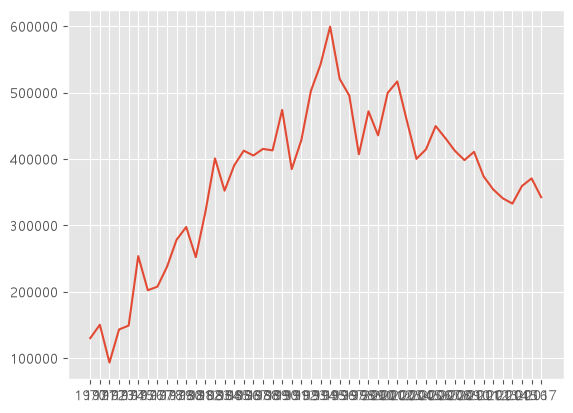

In [139]:
plt.plot(sr_one.index, sr_one.values)
plt.show()

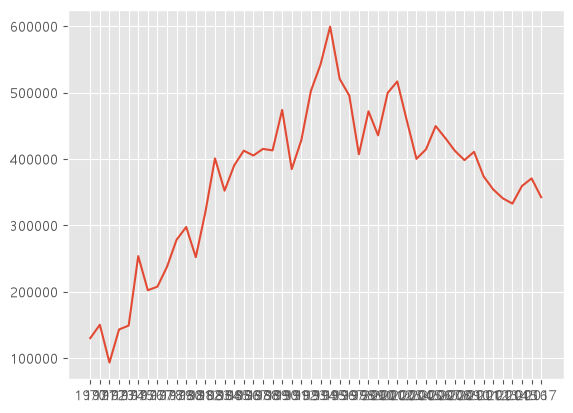

In [140]:
plt.plot(sr_one)
plt.show()

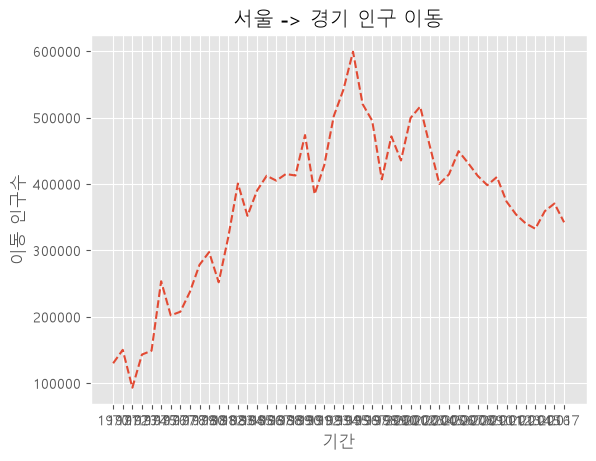

In [141]:
# 차트제목 / 축 이름 / 선 스타일
from matplotlib import font_manager, rc
font_path = "./data/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc("font", family=font_name)

plt.plot(sr_one.index, sr_one.values, linestyle="--")

plt.title("서울 -> 경기 인구 이동")
plt.xlabel("기간")
plt.ylabel("이동 인구수")

plt.show()

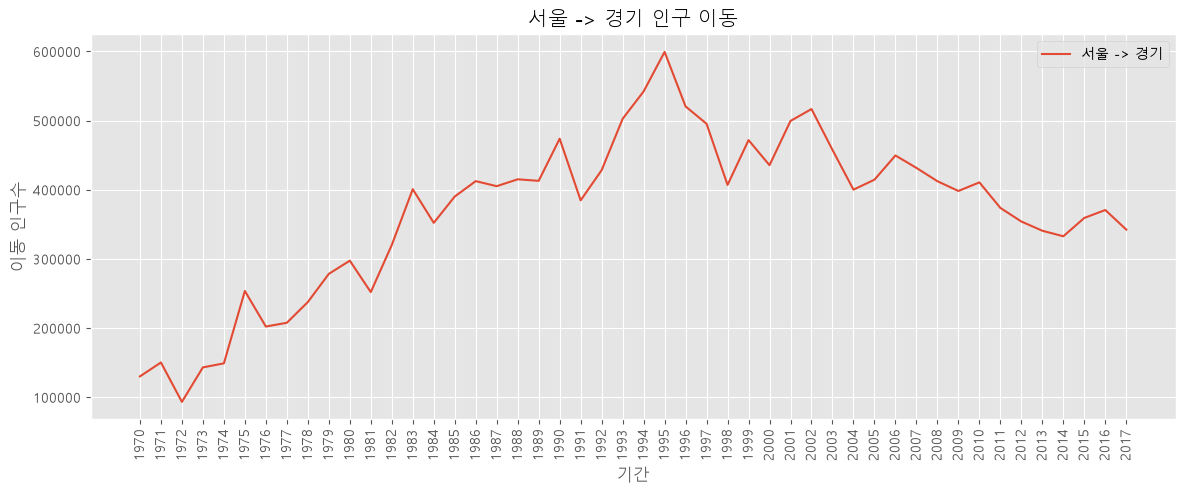

In [142]:
# 그래프 꾸미기
sr_one = df_seoul.loc["경기도"]

plt.figure(figsize=(14,5))
plt.xticks(rotation="vertical")
plt.plot(sr_one.index, sr_one.values)

plt.title("서울 -> 경기 인구 이동")
plt.xlabel("기간")
plt.ylabel("이동 인구수")

plt.legend(labels=["서울 -> 경기"], loc="best")

plt.show()

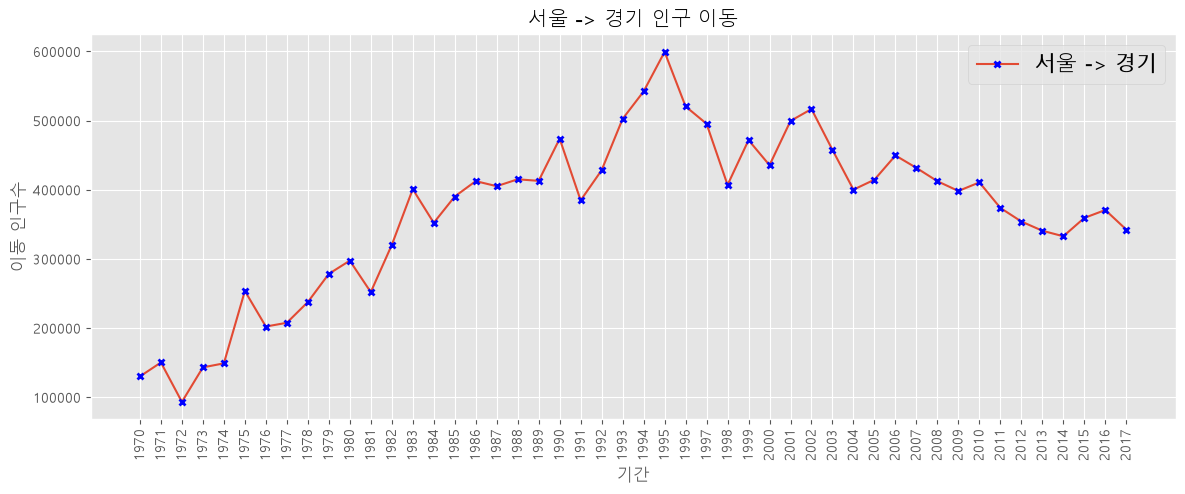

In [143]:
sr_one

plt.style.use("ggplot")
plt.figure(figsize=(14, 5))

plt.xticks(rotation="vertical")

plt.plot(
    sr_one.index, 
    sr_one.values,
    marker="x",
    markerfacecolor="red",
    markeredgecolor="blue",
    markeredgewidth=2,
    markersize=5
)

plt.title("서울 -> 경기 인구 이동")
plt.xlabel("기간")
plt.ylabel("이동 인구수")

plt.legend(labels=["서울 -> 경기"], loc="best", fontsize=15)
# plt.show()

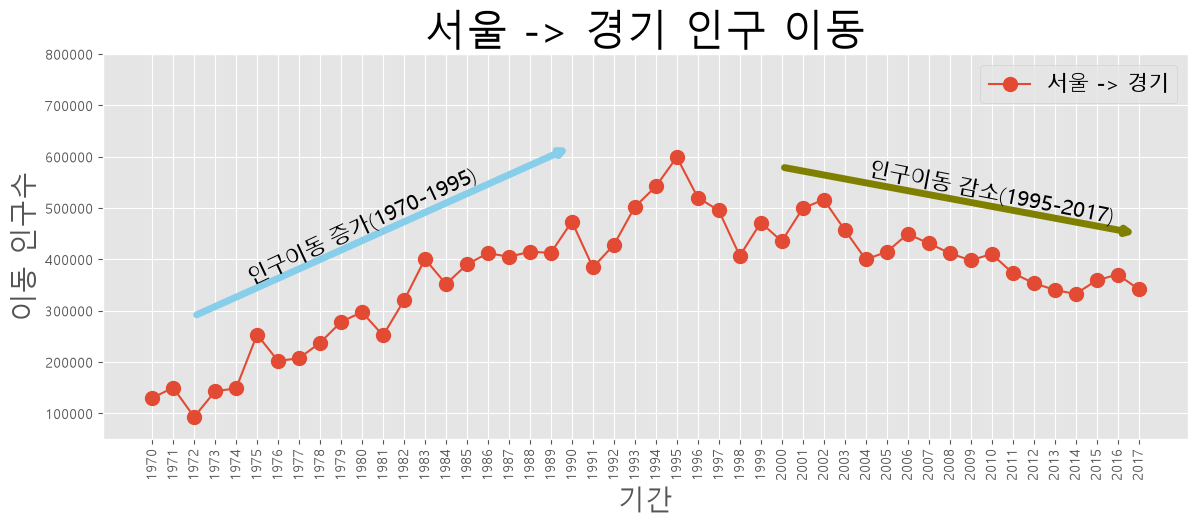

In [144]:
plt.style.use("ggplot")
plt.figure(figsize=(14, 5))
plt.xticks(size=10, rotation="vertical")
plt.plot(sr_one.index, sr_one.values, marker="o", markersize=10)

plt.title("서울 -> 경기 인구 이동", size=30)
plt.xlabel("기간", size=20)
plt.ylabel("이동 인구수", size=20)

plt.legend(labels=["서울 -> 경기"], loc="best", fontsize=15)

plt.ylim(50000, 800000)

plt.annotate("",
             xy=(20,620000),
             xytext=(2, 290000),
             xycoords="data",
             arrowprops=dict(arrowstyle="->", color="skyblue", lw=5))

plt.annotate("",
             xy=(47,450000),
             xytext=(30, 580000),
             xycoords="data",
             arrowprops=dict(arrowstyle="->", color="olive", lw=5))

plt.annotate("인구이동 증가(1970-1995)",
             xy=(10, 350000),
             rotation=25,
             va="baseline",
             ha="center",
             fontsize=15)

plt.annotate("인구이동 감소(1995-2017)",
             xy=(40, 470000),
             rotation=-11,
             va="baseline",
             ha="center",
             fontsize=15)

plt.show()

In [145]:
# Figure객체, Axes 객체
import pandas as pd
import matplotlib.pyplot as plt

samsung_revenue = pd.read_csv("./data/삼성전자_분기별_매출액.csv")
samsung_revenue.head()
samsung_revenue.info()
samsung_revenue = samsung_revenue.sort_values("quarter")
samsung_revenue

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   value    6 non-null      int64
 1   quarter  6 non-null      str  
dtypes: int64(1), str(1)
memory usage: 228.0 bytes


,value,quarter
5,77203607000000,2022-Q2
4,76781680000000,2022-Q3
3,70464575000000,2022-Q4
2,63745371000000,2023-Q1
1,60005533000000,2023-Q2
0,67404652000000,2023-Q3


In [146]:
fig = plt.figure()
fig

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

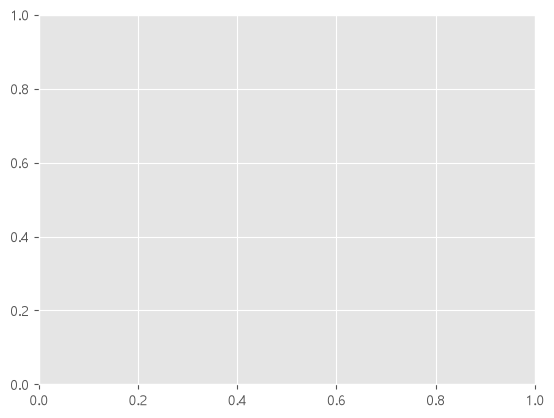

In [147]:
fig, axe = plt.subplots()

# plt.subplots()


In [148]:
print(fig)

Figure(640x480)


In [149]:
print(axe)

Axes(0.125,0.11;0.775x0.77)


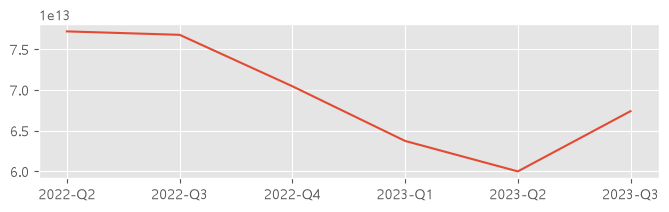

In [150]:
fig, axe = plt.subplots(figsize=(8, 2))
axe.plot(samsung_revenue["quarter"], samsung_revenue["value"])

Figure(640x480)


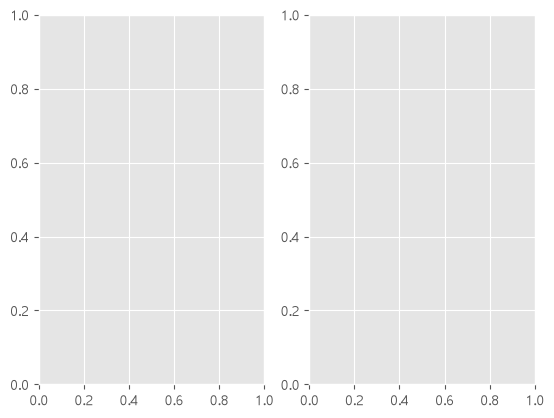

In [151]:
fig, axes = plt.subplots(1, 2)
print(fig)

In [152]:
print(axes)

[<Axes: > <Axes: >]


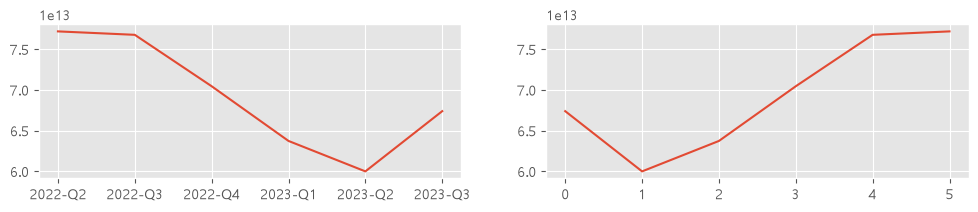

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(12, 2))

axes[0].plot(samsung_revenue["quarter"], samsung_revenue["value"])
# axes[1].plot(samsung_revenue["quarter"], samsung_revenue["value"])
samsung_revenue["value"].plot(ax=axes[1])
plt.show()


Figure(640x480)
[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]


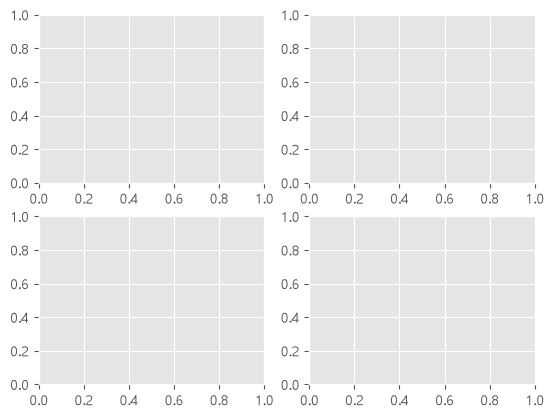

In [154]:
fig, axes = plt.subplots(2, 2)
print(fig)
print(axes)

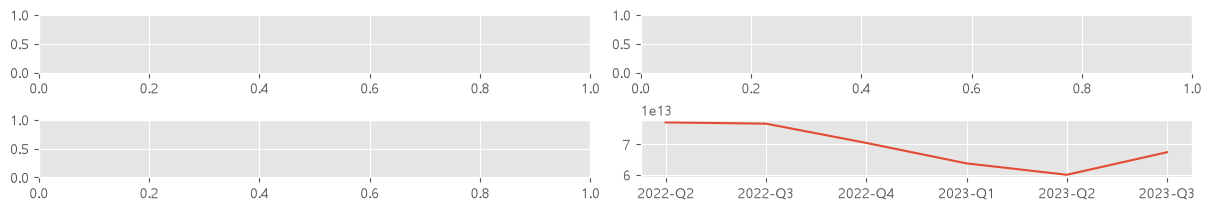

In [155]:
fig, axes = plt.subplots(2, 2, figsize=(12, 2), constrained_layout=True)
axes[1,1].plot(samsung_revenue["quarter"], samsung_revenue["value"])
plt.show()

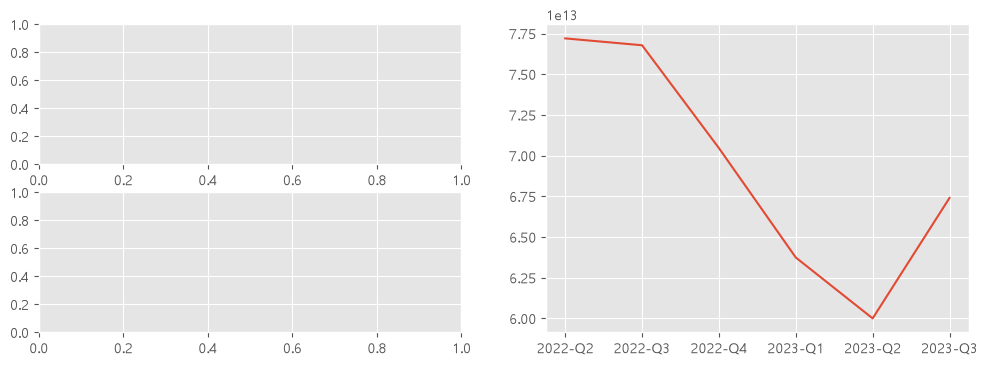

In [156]:
fig, axes = plt.subplot_mosaic([
    ["top_left", "right"],
    ["bottom_left", "right"]],
    figsize=(12, 4)
)

axes["right"].plot(samsung_revenue["quarter"], samsung_revenue["value"])
plt.show()

Figure(640x480)
{'d': <Axes: label='d'>, 'c': <Axes: label='c'>, 'a': <Axes: label='a'>, 'x': <Axes: label='x'>, 'z': <Axes: label='z'>, 'g': <Axes: label='g'>}


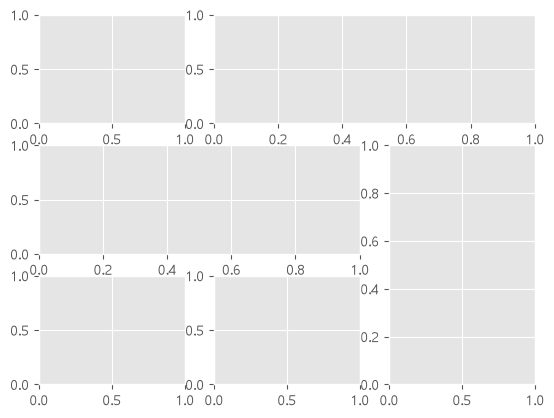

In [157]:
fig, axes = plt.subplot_mosaic([
    ["d", "c", "c"],
    ["a", "a", "x"],
    ["z", "g", "x"]
])

print(fig)
print(axes)

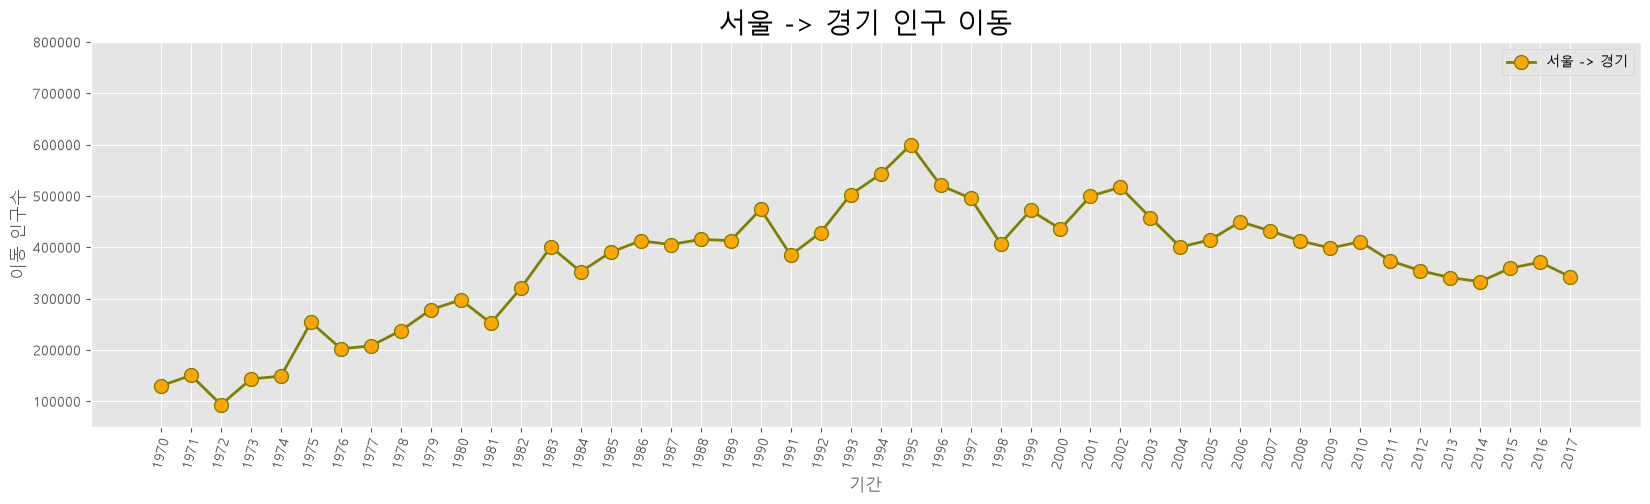

In [158]:
# fig, axes = plt.subplot_mosaic([
#     ["top_left", "right"],
#     ["bottom_left", "right"]],
#     figsize=(12, 4)
# )

# axes["right"].plot(samsung_revenue["quarter"], samsung_revenue["value"])

plt.style.use("ggplot")

fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(sr_one, marker="o", markerfacecolor="orange", markersize=10, color="olive", linewidth=2, label="서울 -> 경기")
ax.legend(loc="best")

ax.set_ylim(50000, 800000)

ax.set_title("서울 -> 경기 인구 이동", size=20)

ax.set_xlabel("기간", size=12)
ax.set_ylabel("이동 인구수", size=12)

ax.set_xticks(sr_one.index)
ax.set_xticklabels(sr_one.index, rotation=75)

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

plt.show()


In [159]:
col_years = list(map(str, range(1970, 2018)))
df_3 = df_seoul.loc[["충청남도", "경상북도", "강원도"], col_years]

df_3

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,,,,,,,,,,,,,,
충청남도,15954,18943,23406,27139,25509,51205,41447,43993,48091,45388,...,27458,24889,24522,24723,22269,21486,21473,22299,21741,21020
경상북도,11868,16459,22073,27531,26902,46177,40376,41155,42940,43565,...,15425,16569,16042,15818,15191,14420,14456,15113,14236,12464
강원도,9352,12885,13561,16481,15479,27837,25927,25415,26700,27599,...,23668,23331,22736,23624,22332,20601,21173,22659,21590,21016


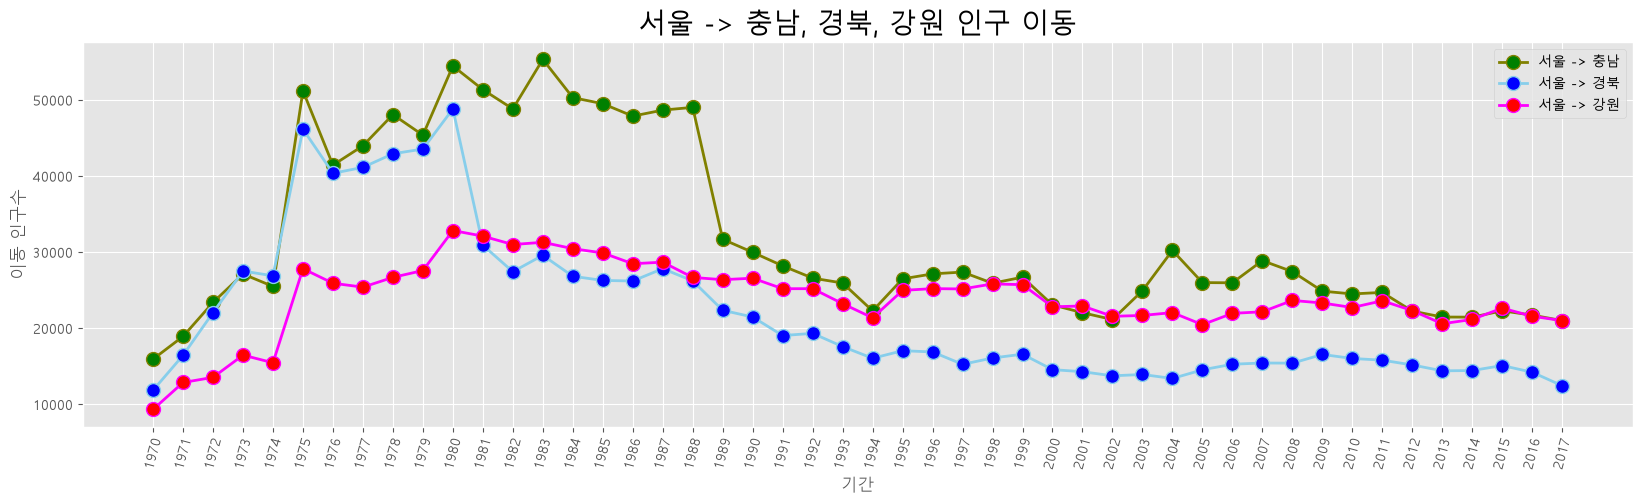

In [160]:

plt.style.use("ggplot")

fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(col_years, df_3.loc["충청남도", :], marker="o", markerfacecolor="green", markersize=10, color="olive", linewidth=2, label="서울 -> 충남")
ax.plot(col_years, df_3.loc["경상북도", :], marker="o", markerfacecolor="blue", markersize=10, color="skyblue", linewidth=2, label="서울 -> 경북")
ax.plot(col_years, df_3.loc["강원도", :], marker="o", markerfacecolor="red", markersize=10, color="magenta", linewidth=2, label="서울 -> 강원")



ax.legend(loc="best")


ax.set_title("서울 -> 충남, 경북, 강원 인구 이동", size=20)

ax.set_xlabel("기간", size=12)
ax.set_ylabel("이동 인구수", size=12)

ax.set_xticks(range(len(col_years)))
ax.set_xticklabels(col_years, rotation=75)

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

plt.show()


In [161]:
col_years = list(map(str, range(1970, 2018)))
df_4 = df_seoul.loc[["충청남도", "경상북도", "강원도", "전라남도"], col_years]

df_4

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,,,,,,,,,,,,,,
충청남도,15954,18943,23406,27139,25509,51205,41447,43993,48091,45388,...,27458,24889,24522,24723,22269,21486,21473,22299,21741,21020
경상북도,11868,16459,22073,27531,26902,46177,40376,41155,42940,43565,...,15425,16569,16042,15818,15191,14420,14456,15113,14236,12464
강원도,9352,12885,13561,16481,15479,27837,25927,25415,26700,27599,...,23668,23331,22736,23624,22332,20601,21173,22659,21590,21016
전라남도,10513,16755,20157,22160,21314,46610,46251,43430,44624,47934,...,16601,17468,16429,15974,14765,14187,14591,14598,13065,12426


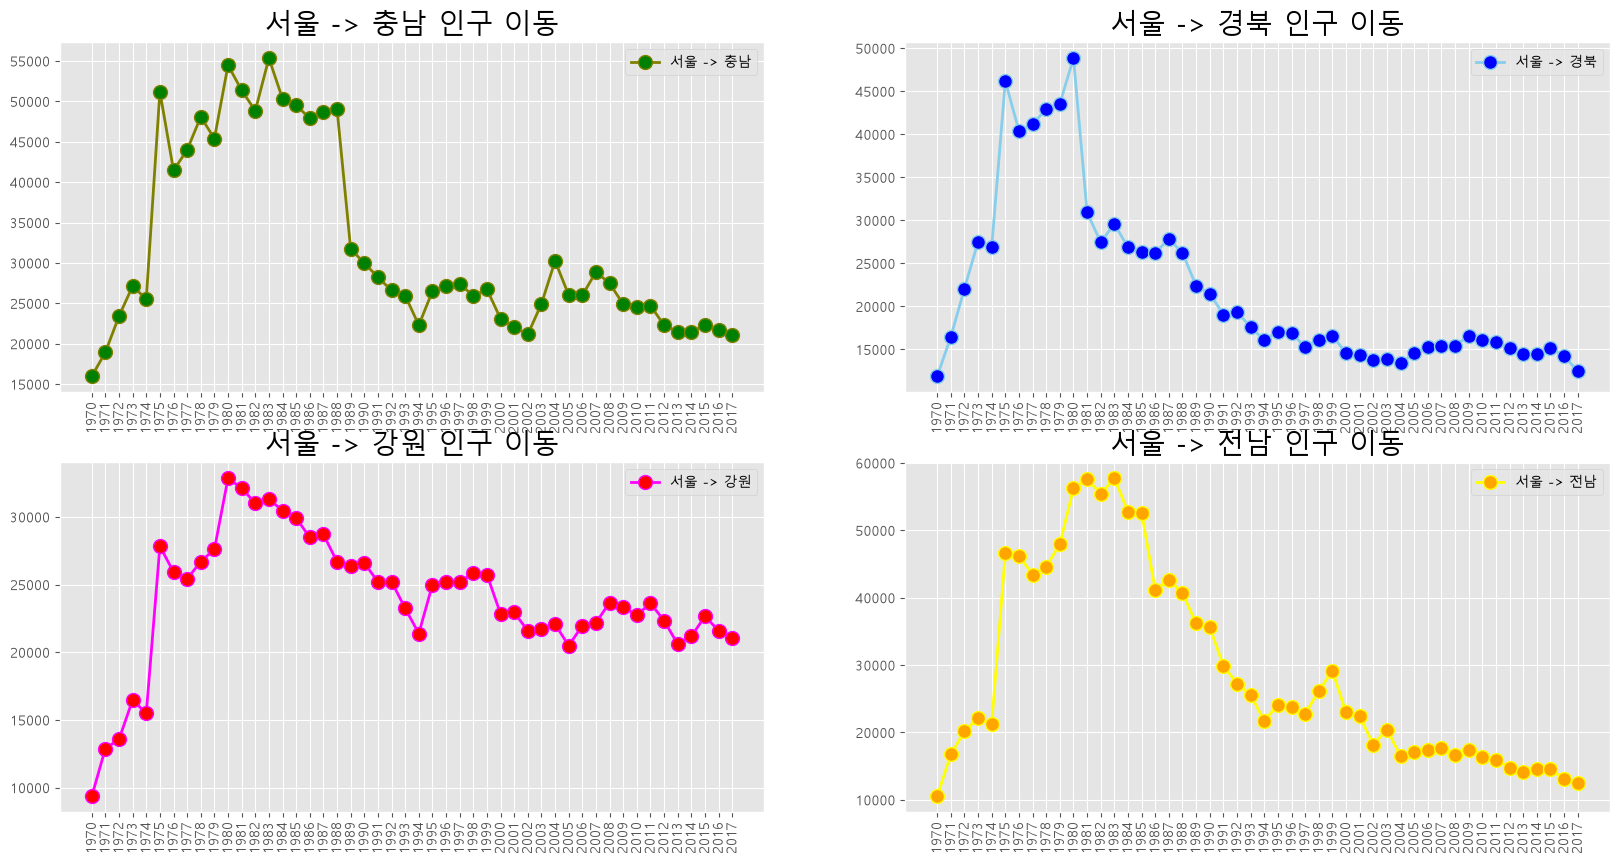

In [162]:

plt.style.use("ggplot")


fig, axes = plt.subplot_mosaic([
    ["top_left", "top_right"],
    ["bottom_left", "bottom_right"]],
    figsize=(20, 10)
)

axes["top_left"].plot(col_years, df_4.loc["충청남도", :], marker="o", markerfacecolor="green", markersize=10, color="olive", linewidth=2, label="서울 -> 충남")
axes["top_right"].plot(col_years, df_4.loc["경상북도", :], marker="o", markerfacecolor="blue", markersize=10, color="skyblue", linewidth=2, label="서울 -> 경북")
axes["bottom_left"].plot(col_years, df_4.loc["강원도", :], marker="o", markerfacecolor="red", markersize=10, color="magenta", linewidth=2, label="서울 -> 강원")
axes["bottom_right"].plot(col_years, df_4.loc["전라남도", :], marker="o", markerfacecolor="orange", markersize=10, color="yellow", linewidth=2, label="서울 -> 전남")




axes["top_left"].legend(loc="best")
axes["top_right"].legend(loc="best")
axes["bottom_left"].legend(loc="best")
axes["bottom_right"].legend(loc="best")


axes["top_left"].set_title("서울 -> 충남 인구 이동", size=20)
axes["top_right"].set_title("서울 -> 경북 인구 이동", size=20)
axes["bottom_left"].set_title("서울 -> 강원 인구 이동", size=20)
axes["bottom_right"].set_title("서울 -> 전남 인구 이동", size=20)


axes["top_left"].set_xticks(range(len(col_years)))
axes["top_right"].set_xticks(range(len(col_years)))
axes["bottom_left"].set_xticks(range(len(col_years)))
axes["bottom_right"].set_xticks(range(len(col_years)))

axes["top_left"].set_xticklabels(col_years, rotation=90)
axes["top_right"].set_xticklabels(col_years, rotation=90)
axes["bottom_left"].set_xticklabels(col_years, rotation=90)
axes["bottom_right"].set_xticklabels(col_years, rotation=90)

plt.show()


In [163]:
col_years = list(map(str, range(1970, 2017)))
df_seoul.loc[["충청남도", "경상북도", "강원도", "전라남도"], col_years]
df_4.dtypes
df_4.head()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,,,,,,,,,,,,,,
충청남도,15954,18943,23406,27139,25509,51205,41447,43993,48091,45388,...,27458,24889,24522,24723,22269,21486,21473,22299,21741,21020
경상북도,11868,16459,22073,27531,26902,46177,40376,41155,42940,43565,...,15425,16569,16042,15818,15191,14420,14456,15113,14236,12464
강원도,9352,12885,13561,16481,15479,27837,25927,25415,26700,27599,...,23668,23331,22736,23624,22332,20601,21173,22659,21590,21016
전라남도,10513,16755,20157,22160,21314,46610,46251,43430,44624,47934,...,16601,17468,16429,15974,14765,14187,14591,14598,13065,12426


In [164]:
df_4 = df_4.T
df_4.head()

전입지,충청남도,경상북도,강원도,전라남도
1970,15954,11868,9352,10513
1971,18943,16459,12885,16755
1972,23406,22073,13561,20157
1973,27139,27531,16481,22160
1974,25509,26902,15479,21314


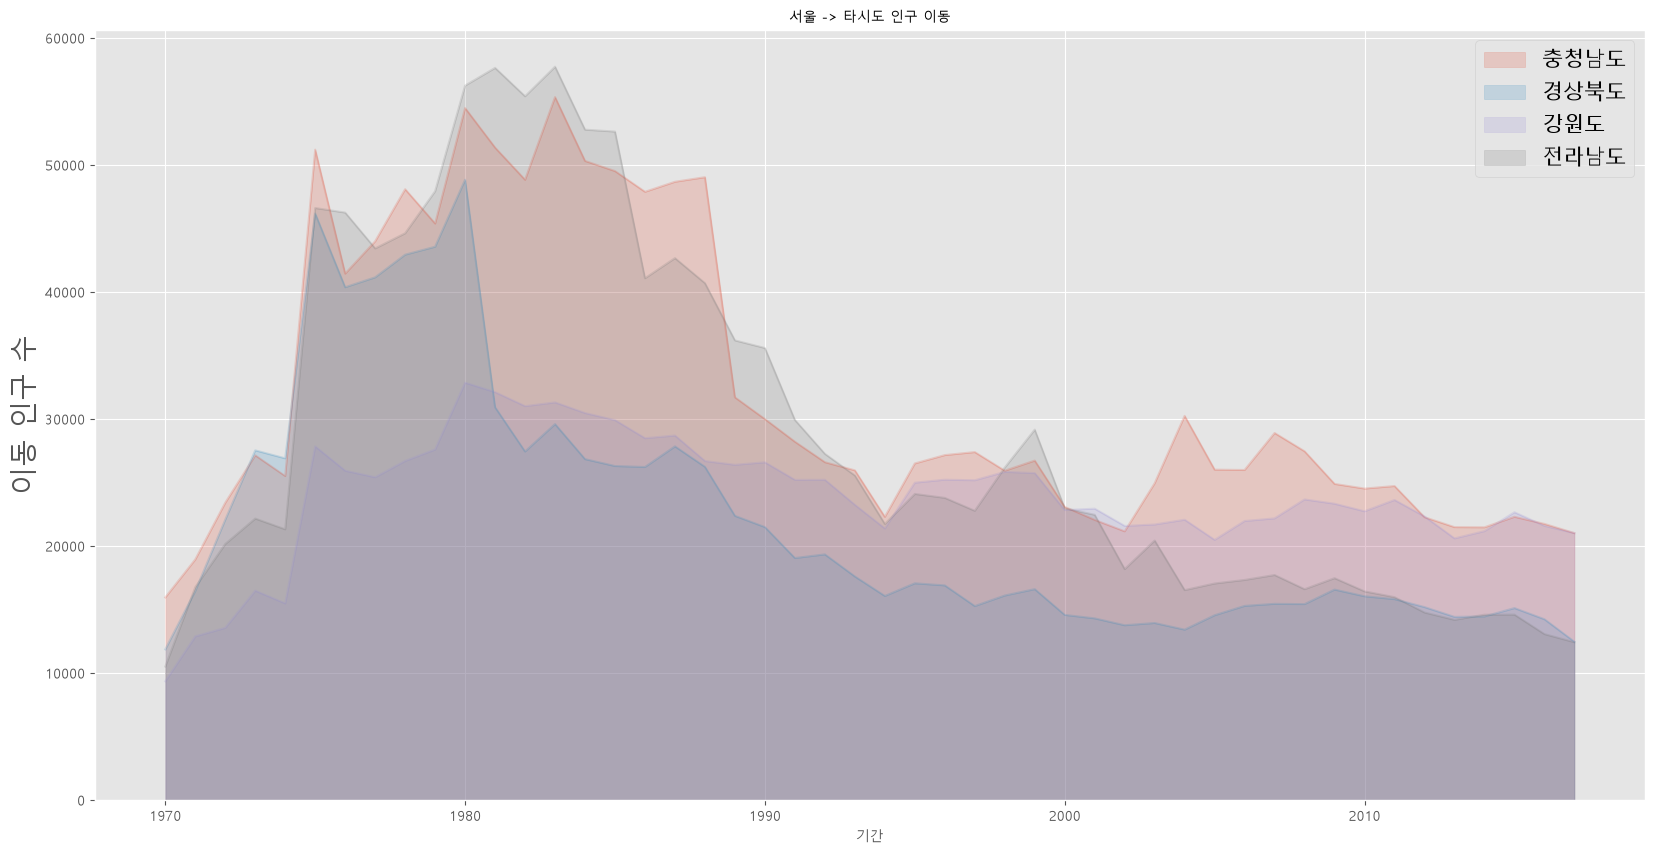

In [165]:
plt.style.use("ggplot")

df_4.plot(kind="area", stacked=False, alpha=0.2, figsize=(20,10))

plt.title("서울 -> 타시도 인구 이동", size=10)
plt.ylabel("이동 인구 수", size=20)
plt.xlabel("기간", size=10)
plt.legend(loc="best", fontsize=15)

plt.show()


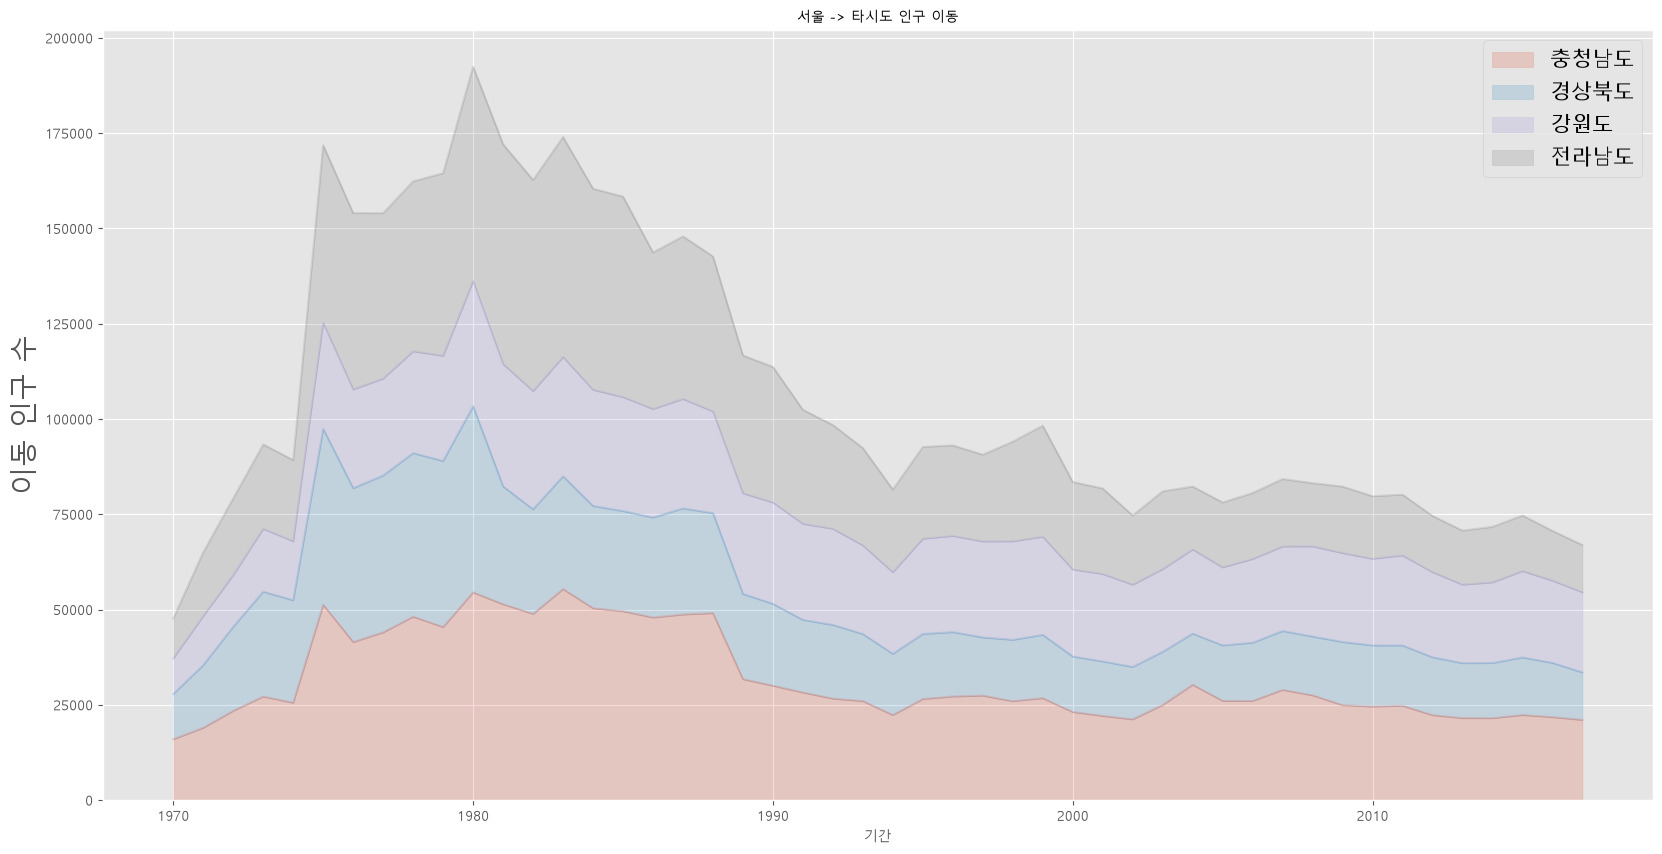

In [166]:
plt.style.use("ggplot")

df_4.plot(kind="area", stacked=True, alpha=0.2, figsize=(20,10))

plt.title("서울 -> 타시도 인구 이동", size=10)
plt.ylabel("이동 인구 수", size=20)
plt.xlabel("기간", size=10)
plt.legend(loc="best", fontsize=15)

plt.show()


In [168]:
# 막대그래프
df_4.head(10)
df_4.index = df_4.index.map(int)
df_4.head(10)

전입지,충청남도,경상북도,강원도,전라남도
1970,15954,11868,9352,10513
1971,18943,16459,12885,16755
1972,23406,22073,13561,20157
1973,27139,27531,16481,22160
1974,25509,26902,15479,21314
1975,51205,46177,27837,46610
1976,41447,40376,25927,46251
1977,43993,41155,25415,43430
1978,48091,42940,26700,44624
1979,45388,43565,27599,47934


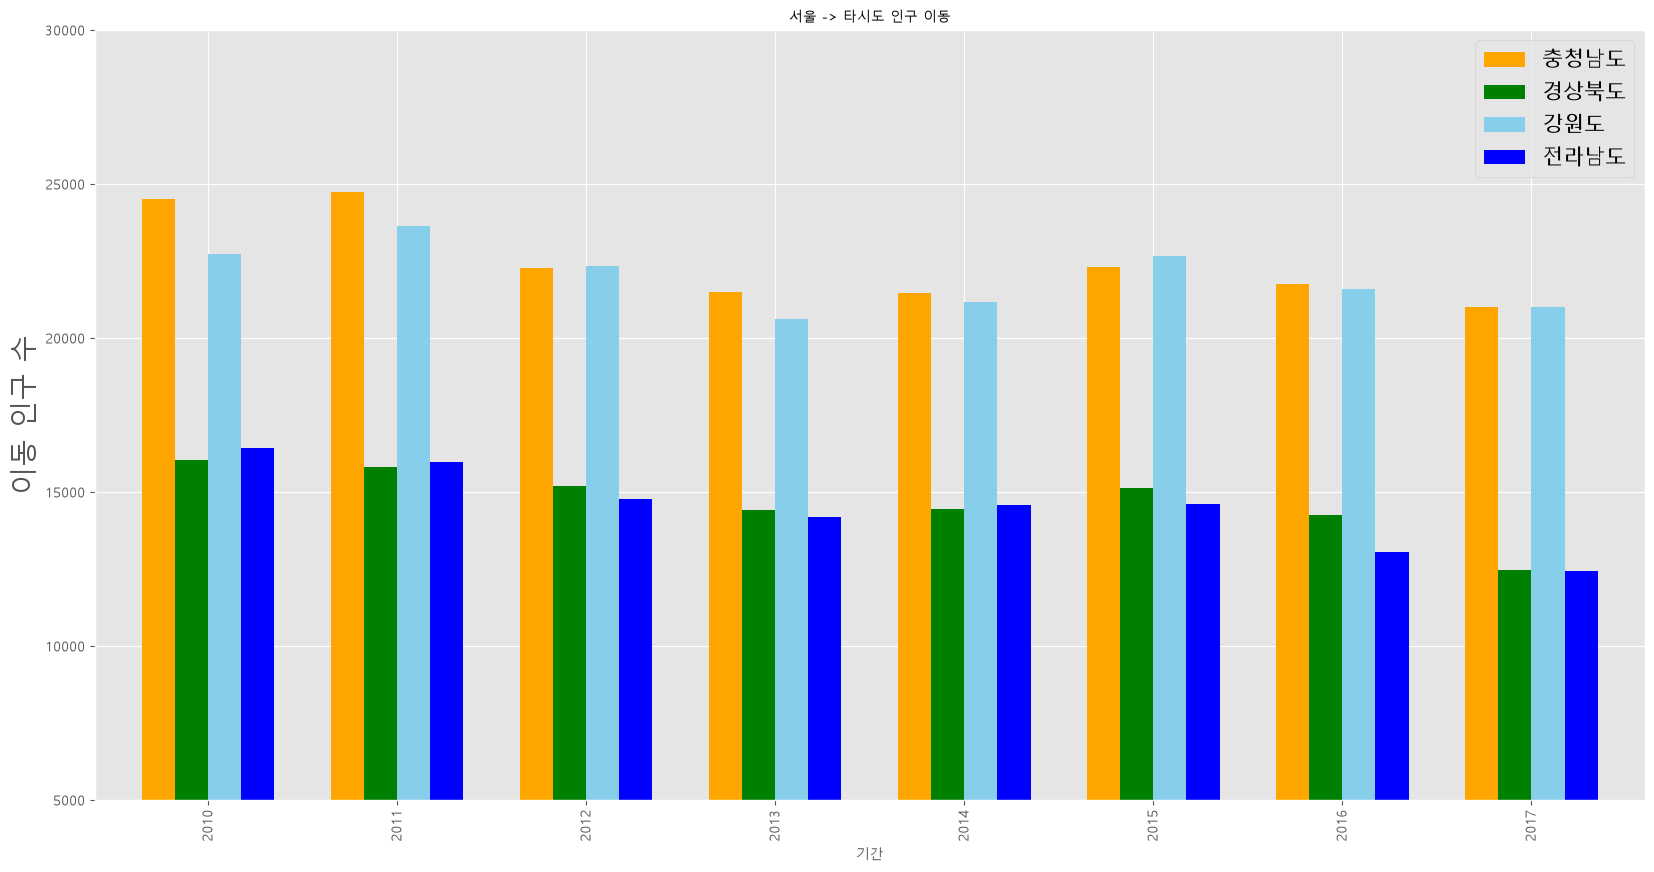

In [172]:
col_years = list(list(map(str, range(2010, 2018))))
df_4 = df_seoul.loc[["충청남도", "경상북도", "강원도", "전라남도"], col_years]
df_4 = df_4.T

df_4.plot(kind="bar", figsize=(20, 10), width=0.7, color=["orange", "green", "skyblue", "blue"])

plt.title("서울 -> 타시도 인구 이동", size=10)
plt.ylabel("이동 인구 수", size=20)
plt.xlabel("기간", size=10)
plt.ylim(5000, 30000)
plt.legend(loc="best", fontsize=15)

plt.show()

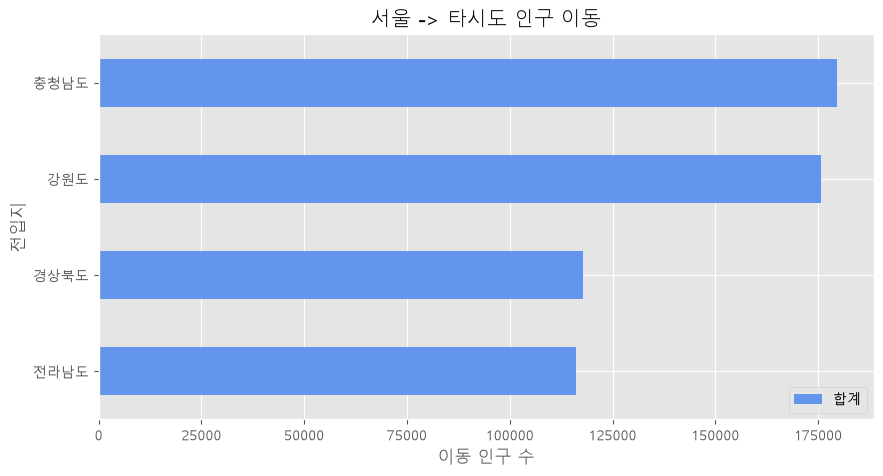

In [173]:
col_years = list(list(map(str, range(2010, 2018))))
df_4 = df_seoul.loc[["충청남도", "경상북도", "강원도", "전라남도"], col_years]

df_4["합계"] = df_4.sum(axis=1)

df_total = df_4[["합계"]].sort_values(by="합계", ascending=True)
df_total.plot(kind="barh", color="cornflowerblue", width=0.5, figsize=(10, 5))

plt.style.use("ggplot")

plt.title("서울 -> 타시도 인구 이동")
plt.ylabel("전입지")
plt.xlabel("이동 인구 수")

plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib import font_manager, rc
font_path = "./data/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc("font", family=font_name)


plt.style.use("ggplot")
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_excel("./data/남북한발전전력량.xlsx")
df = df.loc[5:9]
df.drop("전력량 (억㎾h)", axis="columns", inplace=True)
df.set_index("발전 전력별", inplace=True)
df = df.T
df.head()

발전 전력별,합계,수력,화력,원자력
1990,277,156,121,-
1991,263,150,113,-
1992,247,142,105,-
1993,221,133,88,-
1994,231,138,93,-


In [7]:
for col in df.columns:
    df[col] = df[col].replace("-", "0")

df = df.astype(float)
df.head()

발전 전력별,합계,수력,화력,원자력
1990,277.0,156.0,121.0,0.0
1991,263.0,150.0,113.0,0.0
1992,247.0,142.0,105.0,0.0
1993,221.0,133.0,88.0,0.0
1994,231.0,138.0,93.0,0.0


In [ ]:
df = df.rename(columns={"합계":"총발전량"})
df["총발전량 - 1년"] = df["총발전량"].shift(1) # shift -> 한칸 아래로 옮기기
df["증감율"] = ((df["총발전량"] / df["총발전량 - 1년"]) - 1) * 100

df.head()

발전 전력별,총발전량,수력,화력,원자력,총발전량 - 1년,증감율
1990,277.0,156.0,121.0,0.0,NaN,NaN
1991,263.0,150.0,113.0,0.0,277.0,-5.054152
1992,247.0,142.0,105.0,0.0,263.0,-6.083650
1993,221.0,133.0,88.0,0.0,247.0,-10.526316
1994,231.0,138.0,93.0,0.0,221.0,4.524887


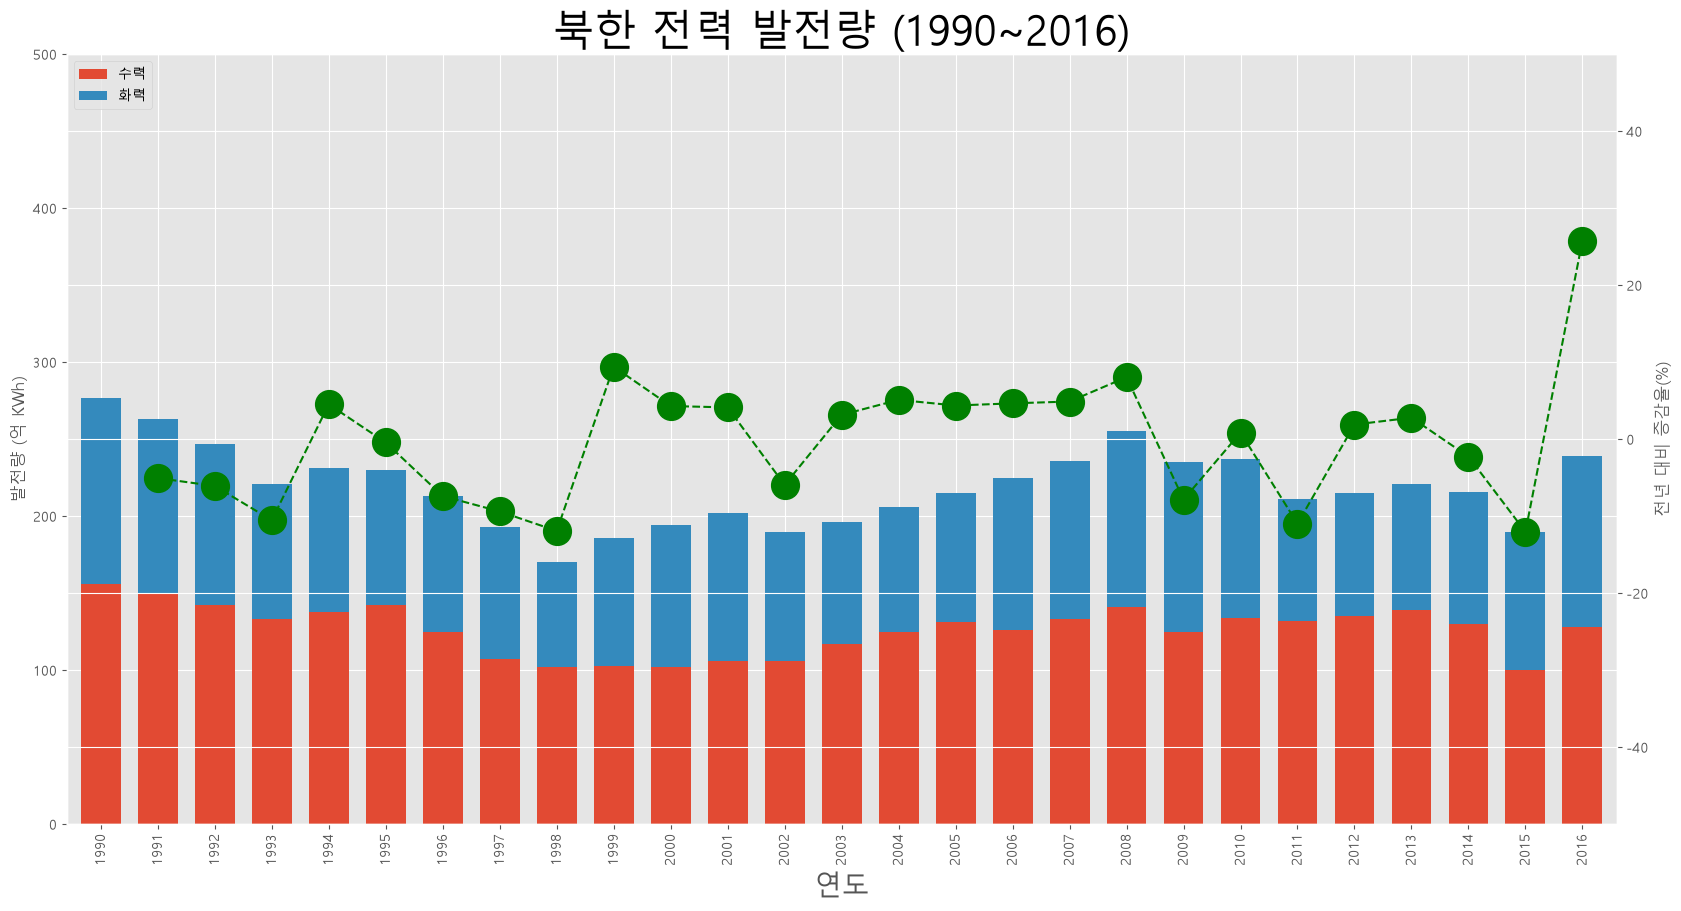

In [19]:
ax1 = df[["수력", "화력"]].plot(kind="bar", figsize=(20, 10), width=0.7, stacked=True)
ax2 = ax1.twinx()

ax2.plot(df.index, df.증감율, ls="--", marker="o", markersize=20, color="green", label="전년대비 증감율(%)")

ax1.set_ylim(0, 500)
ax2.set_ylim(-50, 50)

ax1.set_xlabel("연도", size=20)
ax1.set_ylabel("발전량 (억 KWh)")
ax2.set_ylabel("전년 대비 증감율(%)")

plt.title("북한 전력 발전량 (1990~2016)", size=30)
ax1.legend(loc="upper left")

plt.show()

In [ ]:
ax2.plot(df.index, df.증감율, ls="--", marker="o", markersize=20, color="green", label="전년대비 증감율(%)")

ax1.set_ylim(0, 500)
ax2.set_ylim(-50, 50)

ax1.set_xlabel("연도", size=20)
ax1.set_ylabel("발전량")

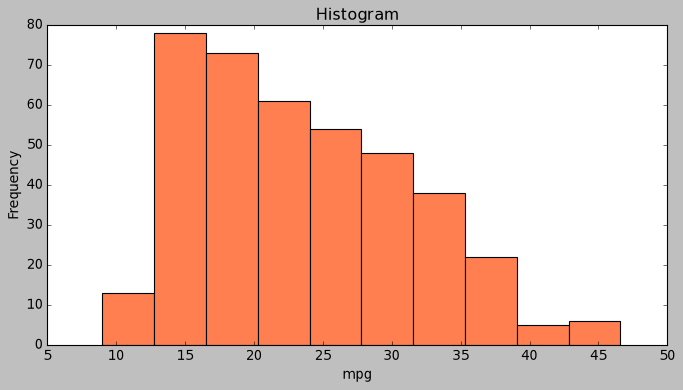

In [21]:
# 히스토그램
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("classic")

df = pd.read_csv("./data/auto-mpg.csv", header=None)

df.columns = [
    'mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
    'acceleration', 'model year', 'origin', 'name'
]

df["mpg"].plot(kind="hist", bins=10, color="coral", figsize=(10,5))

plt.title("Histogram")
plt.xlabel("mpg")
plt.show()

array([<Axes: title={'center': '1'}, ylabel='Frequency'>,
       <Axes: title={'center': '2'}, ylabel='Frequency'>,
       <Axes: title={'center': '3'}, ylabel='Frequency'>], dtype=object)

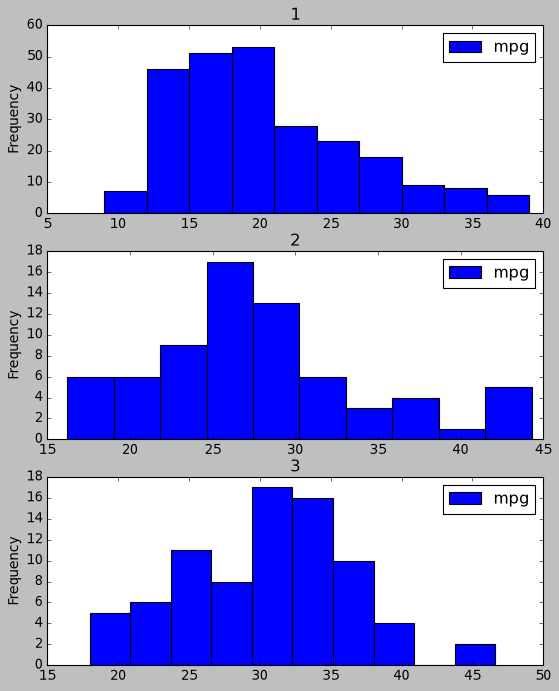

In [22]:
df[["mpg", "origin"]].plot(by=["origin"], kind="hist", figsize=(8, 10))

array([<Axes: title={'center': '(1, 4)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(1, 6)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(1, 8)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(2, 4)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(2, 5)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(2, 6)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(3, 3)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(3, 4)'}, ylabel='Frequency'>,
       <Axes: title={'center': '(3, 6)'}, ylabel='Frequency'>],
      dtype=object)

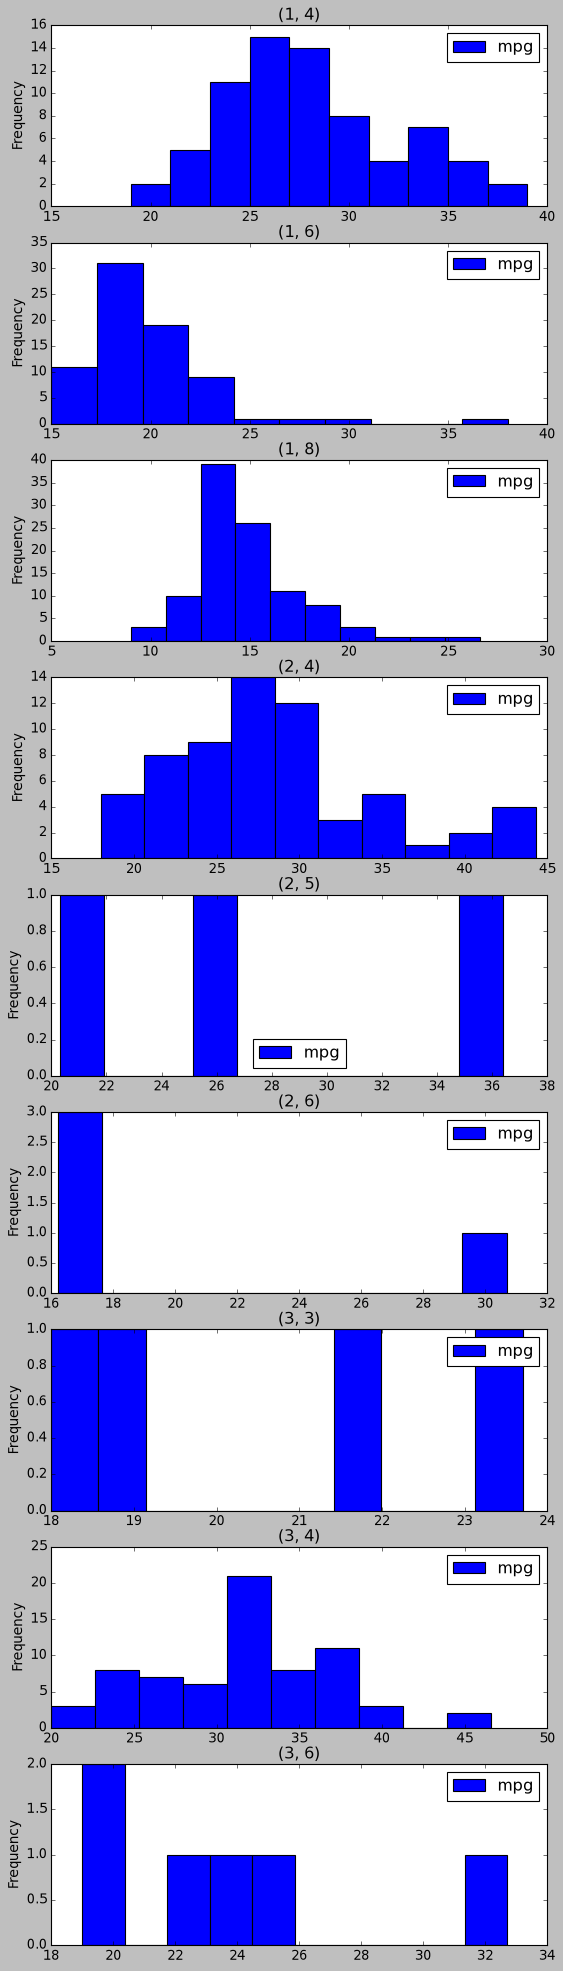

In [23]:
df[["mpg", "origin", "cylinders"]].plot(by=["origin", "cylinders"], kind="hist", figsize=(8, 30))

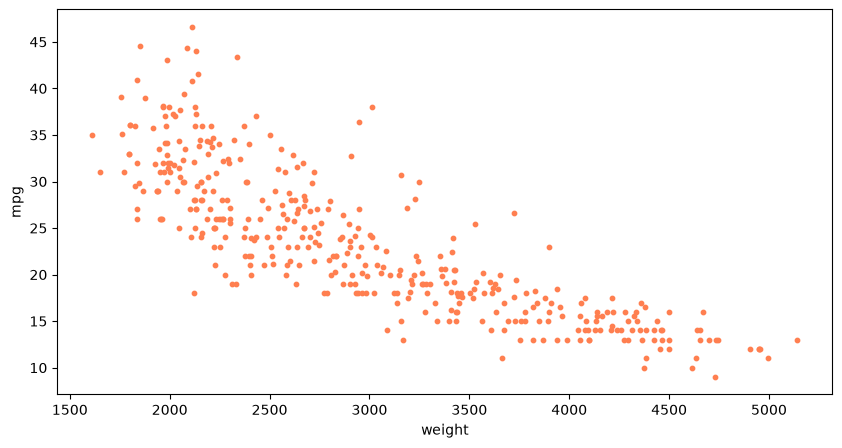

In [24]:
# 산점도
plt.style.use("default")

df.plot(kind="scatter", x="weight", y="mpg", c="coral", s=10, figsize=(10, 5))
plt.show()

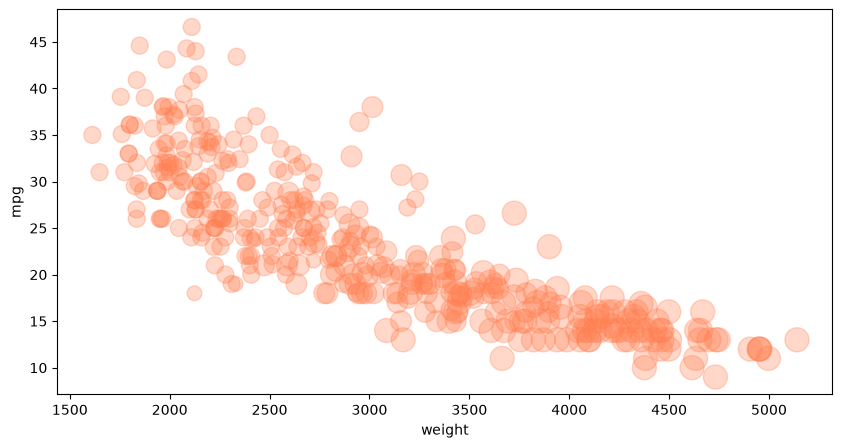

In [26]:
plt.style.use("default")

cylinders_size = (df.cylinders / df.cylinders.max()) * 300

df.plot(kind="scatter", x="weight", y="mpg", c="coral", figsize=(10, 5), s=cylinders_size, alpha=0.3)
plt.show()

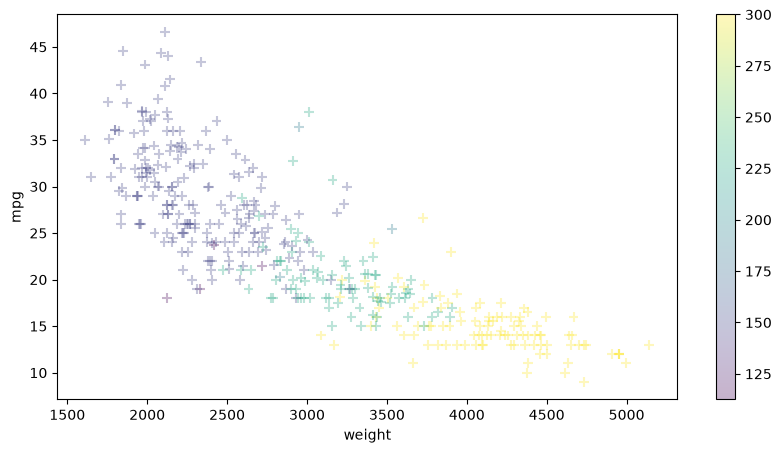

In [29]:
plt.style.use("default")

cylinders_size = (df.cylinders / df.cylinders.max()) * 300

df.plot(kind="scatter", x="weight", y="mpg", marker="+", cmap="viridis", c=cylinders_size, figsize=(10, 5), s=50, alpha=0.3)

plt.savefig("./data/scatter.png")
plt.savefig("./data/scatter_transparent.png", transparent=True)


plt.show()

In [31]:
# 파이차트
df["count"] = 1
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   name          398 non-null    str    
 9   count         398 non-null    int64  
dtypes: float64(4), int64(4), str(2)
memory usage: 31.2 KB


In [32]:
df_origin = df.groupby("origin").sum(numeric_only=True)
df_origin.head()

,mpg,cylinders,displacement,weight,acceleration,model year,count
origin,,,,,,,
1,5000.8,1556,61229.5,837121.0,3743.4,18827,249
2,1952.4,291,7640.0,169631.0,1175.1,5307,70
3,2405.6,324,8114.0,175477.0,1277.6,6118,79


In [33]:
df_origin.index = ["USA", "EU", "JAPAN"]
df_origin.head()

,mpg,cylinders,displacement,weight,acceleration,model year,count
USA,5000.8,1556,61229.5,837121.0,3743.4,18827,249
EU,1952.4,291,7640.0,169631.0,1175.1,5307,70
JAPAN,2405.6,324,8114.0,175477.0,1277.6,6118,79


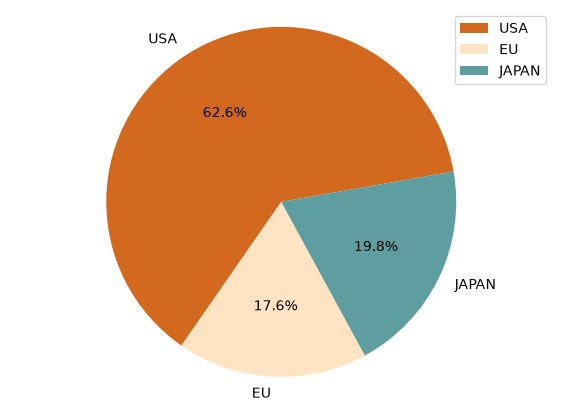

In [35]:
df_origin["count"].plot(kind="pie", autopct="%1.1f%%", startangle=10, colors=["chocolate", "bisque", "cadetblue"] , figsize=(7, 5))
plt.axis("equal")
plt.legend(labels=df_origin.index, loc="upper right")
plt.show()

C:\Users\lgiht\AppData\Local\Temp\ipykernel_21532\1833682952.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax2.boxplot(


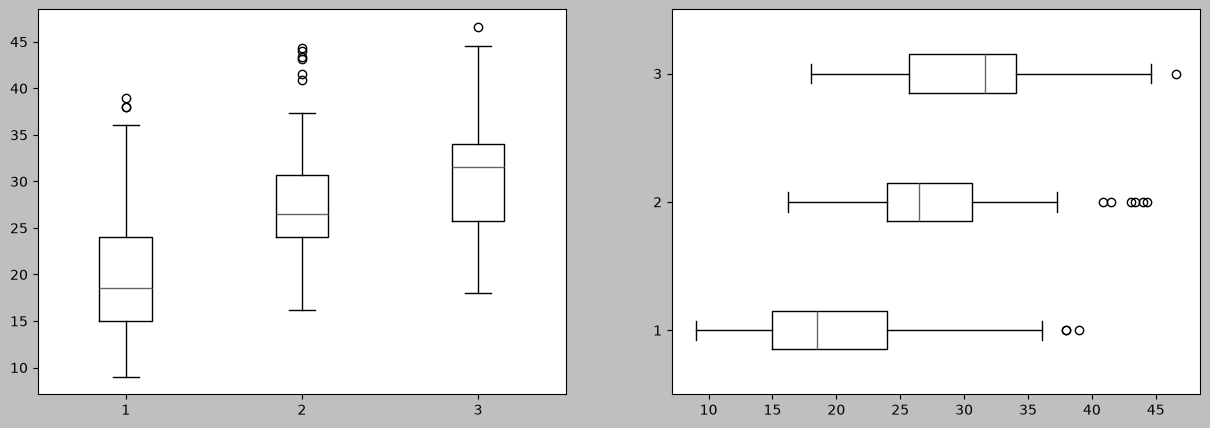

In [41]:
# 박스플롯
plt.style.use("grayscale")
plt.rcParams["axes.unicode_minus"]=False

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.boxplot(
    x=[
        df[df["origin"] == 1]["mpg"],
        df[df["origin"] == 2]["mpg"],
        df[df["origin"] == 3]["mpg"]],
    label=["USA", "EU", "JAPAN"]
)

ax2.boxplot(
    x=[
        df[df["origin"] == 1]["mpg"],
        df[df["origin"] == 2]["mpg"],
        df[df["origin"] == 3]["mpg"]],
    label=["USA", "EU", "JAPAN"],
    vert=False
)

plt.show()